In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import CenteredNorm
from openpmd_viewer import OpenPMDTimeSeries

plt.rcParams["font.size"] = 14

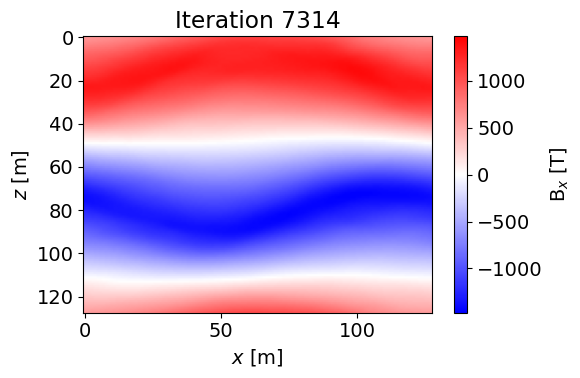

In [2]:
series = OpenPMDTimeSeries("diags/fields/")
iterations = series.iterations

for i in iterations[-1:]:
    fig, ax = plt.subplots(figsize=(6, 4))
    Bx, info_Bx = series.get_field(field="B", coord="x", iteration=i)
    im = ax.imshow(Bx, aspect="auto", cmap="bwr", norm=CenteredNorm())
    ax.set_xlabel(r"$x$ [m]")
    ax.set_ylabel(r"$z$ [m]")
    ax.set_title(f"Iteration {i}")
    fig.colorbar(im, ax=ax, label=r"B$_x$ [T]")
    fig.tight_layout()
plt.show()

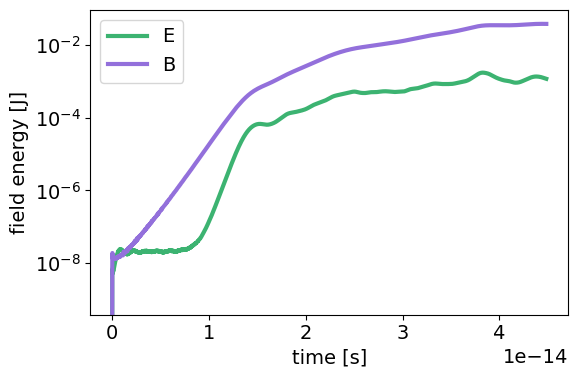

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

FE = pd.read_csv("diags/reducedfiles/FieldEnergy.txt", sep=" ", header=0)
times = FE[[col for col in FE.columns if f"]time" in col]].to_numpy()
E_energy = FE[[col for col in FE.columns if f"]E_" in col]].to_numpy()
B_energy = FE[[col for col in FE.columns if f"]B_" in col]].to_numpy()

ax.semilogy(times, E_energy, lw=3, color="mediumseagreen", label="E")
ax.semilogy(times, B_energy, lw=3, color="mediumpurple", label="B")

ax.legend()
ax.set_xlabel("time [s]")
ax.set_ylabel("field energy [J]")
fig.tight_layout()
plt.show()